In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Definir o caminho para a pasta no Google Drive
folder_path = '//content/drive/MyDrive/Facens/Especialização - Ciências de Dados/Machine Learning/Naive Bayes/figs'  # Substitua pelo caminho correto

# Listar arquivos na pasta
import os
files = os.listdir(folder_path)
print(files)

['logo_facens.png', 'cm_wiki.png', 'acu_wiki.png', 'recall.png', 'precision.png', 'f_score.png', 'Precisionrecall_img.png', 'arvore_dec.png', 'gau_pdf.PNG']


# <center> <img src="figs/logo_facens.png" alt="Logo Facens" width="110" align="left"/>  <br/> <center>Facens<br/>
</p>

<br/>
  
<font size="3"><center>Prof. Julio Cesar Mastrodomenico</center></font>




# Aprendizado de Máquinas
### 2023PGS2M2
----

## Naive Bayes

Implementação e utilização do algoritimo Naive Bayes

$$ P(y_j|\vec{x}) = \hat{P}(y_{j}) \prod_{x_i \in \vec{x}} \hat{P}(x_{i} | y_{j}) $$

Banco de dados:
- Social_Network_Ads.csv
- Atrib_dataset.csv
- spam.csv
- titanic.csv


### Exercícios

In [31]:
# Exemplo de implementação

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('/content/Atrib_dataset.csv', sep=',', index_col=None)

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [32]:
# Visualização das 6 primeiras linhas do nosso dataset
df_dataset.head(n=6)

,Atrib1,Atrib2,Atrib3,Atrib4,Atrib5,Classe
0,0,0,1,1,0,0
1,0,1,1,0,1,1
2,1,1,1,0,0,1
3,0,0,0,0,0,0
4,1,1,1,0,1,1
5,0,1,1,1,0,1


In [33]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
Y = df_dataset.iloc[:, -1].values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

X: [[0 0 1 1 0]
 [0 1 1 0 1]
 [1 1 1 0 0]
 [0 0 0 0 0]
 [1 1 1 0 1]]
Y: [0 1 1 0 1]


In [34]:
# Probabilidade das Classes
pPositivo = sum(Y==1)/len(Y)
pNegativo = sum(Y==0)/len(Y)

print('Probabilidade da classe ser 1 (Positivo): %1.2f%%' %(pPositivo*100))
print('Probabilidade da classe ser 0 (Negativo): %1.2f%%' %(pNegativo*100))

Probabilidade da classe ser 1 (Positivo): 54.00%
Probabilidade da classe ser 0 (Negativo): 46.00%


In [35]:
def calcular_probabilidades(X, Y):
    """
    CALCULARPROBABILIDADES Computa a probabilidade de ocorrencia de cada
    atributo por rotulo possivel. A funcao retorna dois vetores de tamanho n
    (qtde de atributos), um para cada classe.

    CALCULARPROBABILIDADES(X, Y) calcula a probabilidade de ocorrencia de cada atributo em cada classe.
    Cada vetor de saida tem dimensao (n x 1), sendo n a quantidade de atributos por amostra.
    """

    #  inicializa os vetores de probabilidades
    pAtrPositivo = np.zeros(X.shape[1])
    pAtrNegativo = np.zeros(X.shape[1])

    for i in range(len(X[0])):
        pAtrPositivo[i] = sum(Y[np.where(X[:,i]==1)]==1)/sum(Y==1)
        pAtrNegativo[i] = sum(Y[np.where(X[:,i]==1)]==0)/sum(Y==0)

    ##########################################################################

    return pAtrPositivo, pAtrNegativo

pAtrPositivo, pAtrNegativo = calcular_probabilidades(X,Y)

print('A probabilidade esperada para P(Atributo1=1|Classe=1) = %.2f%%' %(pAtrPositivo[0]*100))

A probabilidade esperada para P(Atributo1=1|Classe=1) = 52.96%


In [36]:
def classificacao(x,pPositivo,pNegativo,pAtrPositivo,pAtrNegativo):
    """
    Classifica se a entrada x pertence a classe 0 ou 1 usando
    as probabilidades extraidas da base de treinamento. Essa funcao
    estima a predicao de x atraves da maior probabilidade da amostra
    pertencer a classe 1 ou 0. Tambem retorna as probabilidades condicionais
    de positivo e negativo, respectivamente.

    """

    #  inicializa a classe e as probabilidades condicionais
    classe = 0;
    probPositivo= 0;
    probNegativo = 0;

    probPositivo = np.prod(abs((1-x)-pAtrPositivo))*pPositivo
    probNegativo = np.prod(abs((1-x)-pAtrNegativo))*pNegativo

    if probPositivo>probNegativo:
        classe = 1
    else:
        classe = 0

    ##########################################################################

    return classe, probPositivo, probNegativo

resultados = np.zeros( X.shape[0] )

for i in range(X.shape[0]):
    resultados[i], probPositivo, probNegativo = classificacao(X[i,:],pPositivo,pNegativo,pAtrPositivo,pAtrNegativo)

# calcular acuracia
acuracia = np.sum(resultados==Y)/len(Y)

print('Acuracia obtida pelo seu classificador foi = %.2f%%\n' %( acuracia*100 ) )

Acuracia obtida pelo seu classificador foi = 76.60%



In [37]:
# Depois do modelo treinado, neste caso com as probabilidades calculadas, podemos
# predizer para um novo valor, seja ele x1_novo
x1_novo = np.array([0,1,0,1,1])

classe, probPositivo, probNegativo = classificacao(x1_novo, pPositivo, pNegativo, pAtrPositivo, pAtrNegativo)

if classe ==1:
    print('\n>>> Predicao = Positivo!')
else:
    print('\n>>> Predicao = Negativo!')

print('\n>>>>>> Prob. Positivo = %0.6f!' %(probPositivo))
print('\n>>>>>> Prob. Negativo = %0.6f!\n\n'  %(probNegativo))


>>> Predicao = Positivo!

>>>>>> Prob. Positivo = 0.019366!

>>>>>> Prob. Negativo = 0.009483!




## Gaussian Naive Bayes

<img src="figs/gau_pdf.png" alt="Gaussian Probability Density Function" width="450" align="center"/>

In [38]:
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [39]:
iris = datasets.load_iris()

In [40]:
X = iris.data
y = iris.target

In [41]:
class GaussianNaiveBayes:
  def __init__(self):
    self.e = np.e
    self.pi = np.pi
    self.prob = None

  def _gets_stats(X,y):
    #Propriedades
    n_amostras, n_caract = X.shape
    n_classes = np.unique(ar=y)

    # Convert n_classes to an integer using len()
    n_classes = len(n_classes)

    # criar os valores dos stats
    mean = np.zeros((n_classes,n_caract)) # Use the integer n_classes here
    var = np.zeros((n_classes,n_caract))
    prior = np.zeros(n_classes)

    for c in range(n_classes):
      X_c = X[y==c]
      mean[c,:] = X_c.mean(axis=0) # Remove X_c argument
      var[c,:] = X_c.var(axis=0) # Remove X_c argument
      prior[c] = X_c.shape[0]/n_amostras

    return mean, var, prior, n_classes

In [42]:
def gaussian_density(X, var, mean):
  const = 1 / np.sqrt(2 * np.pi * var)
  prob = np.exp(-(X - mean) ** 2 / (2 * var))
  return const * prob


In [43]:
def get_class_prob(X, mean, var, prior, n_classes):

  #armazenar posteriors
  posterios = list()

  for c in range(n_classes):
    mean_t = mean[c]
    var_t = var[c]
    prior_t = np.log(prior[c])

    # Added mean_t as an argument to gaussian_density()
    posterior = np.sum(np.log(gaussian_density(X, mean_t, var_t)))
    posterior = prior_t + posterior
    posterios.append(posterior)

  return np.argmax(posterios)




In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [45]:
mean, var, prior, n_classes = GaussianNaiveBayes._gets_stats(X_train, y_train)

In [46]:
X_test[10]

array([5.6, 2.7, 4.2, 1.3])

In [47]:
preds = get_class_prob(X_test[10], mean, var, prior, n_classes)

In [48]:
preds = []
for X in X_test:
  preds.append(get_class_prob(X, mean, var, prior, n_classes))

In [49]:
from sklearn.metrics import accuracy_score, f1_score

In [50]:
accuracy_score(y_test, preds)

0.5333333333333333

In [51]:
np.sum(preds==y_test)/len(y_test)

0.5333333333333333

### Usando a biblioteca do Sklearn

In [52]:
df_dataset

,Atrib1,Atrib2,Atrib3,Atrib4,Atrib5,Classe
0,0,0,1,1,0,0
1,0,1,1,0,1,1
2,1,1,1,0,0,1
3,0,0,0,0,0,0
4,1,1,1,0,1,1
...,...,...,...,...,...,...
495,1,1,0,0,1,1
496,1,0,0,1,1,1
497,0,1,1,1,0,0
498,1,0,1,1,1,0


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# Vamos realizar a divisão do dataset, em treino e teste (validação)
X = df_dataset.iloc[:, 0:-1].values
y = df_dataset.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [55]:
# Utilizando a Gaussian Naive Bayes
from sklearn.naive_bayes import BernoulliNB

# Instanciando a classe
classifier = BernoulliNB()

# Treinando o modelo
classifier.fit(X_train, y_train)


# Realizando o fit, que nada mais é que o treino
# do nosso algoritimo


BernoulliNB()

In [56]:
# Predizendo a classe do novo valor
pred = classifier.predict(X_test)


In [57]:
# Realizando o predict do X_test com todos os valores



In [58]:
# Importando algumas métricas do sklearn
from sklearn.metrics import confusion_matrix, accuracy_score

# Matriz de Confusão
cm = confusion_matrix(y_test, pred)
print(cm)


[[28 11]
 [18 43]]


In [59]:
print(accuracy_score(y_test, pred))

0.71


In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

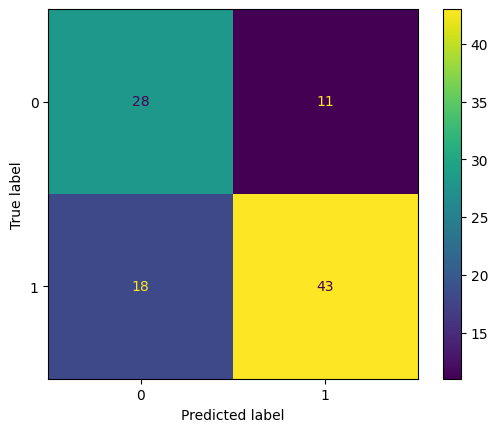

In [61]:
confusion_matrix_display = ConfusionMatrixDisplay(cm)
confusion_matrix_display.plot()
plt.show()

## Métricas:

- Matriz de Confusão

<img src="figs/cm_wiki.png" width="250" height="250" />


- Acurácia

<img src="figs/acu_wiki.png" width="300" height="300" />


- Precisão

<img src="figs/precision.png" width="200" height="200" />


- recall

<img src="figs/recall.png" width="200" height="200" />


- Precisão / Recall

<img src="figs/Precisionrecall_img.png" width="300" height="300" />


- F-Beta Score

<img src="figs/f_score.png" width="200" height="200" />



### Utilizando e visualizando com o Social Ads dataset

In [62]:
# Importando o dataset e separando as variáveis
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [63]:
# Realizando o split do dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


In [64]:
# Vamos ver o que temos na variável X_train
X_train


array([[    44,  39000],
       [    32, 120000],
       [    38,  50000],
       [    32, 135000],
       [    52,  21000],
       [    53, 104000],
       [    39,  42000],
       [    38,  61000],
       [    36,  50000],
       [    36,  63000],
       [    35,  25000],
       [    35,  50000],
       [    42,  73000],
       [    47,  49000],
       [    59,  29000],
       [    49,  65000],
       [    45, 131000],
       [    31,  89000],
       [    46,  82000],
       [    47,  51000],
       [    26,  15000],
       [    60, 102000],
       [    38, 112000],
       [    40, 107000],
       [    42,  53000],
       [    35,  59000],
       [    48,  41000],
       [    48, 134000],
       [    38, 113000],
       [    29, 148000],
       [    26,  15000],
       [    60,  42000],
       [    24,  19000],
       [    42, 149000],
       [    46,  96000],
       [    28,  59000],
       [    39,  96000],
       [    28,  89000],
       [    41,  72000],
       [    45,  26000],


<Axes: ylabel='Count'>

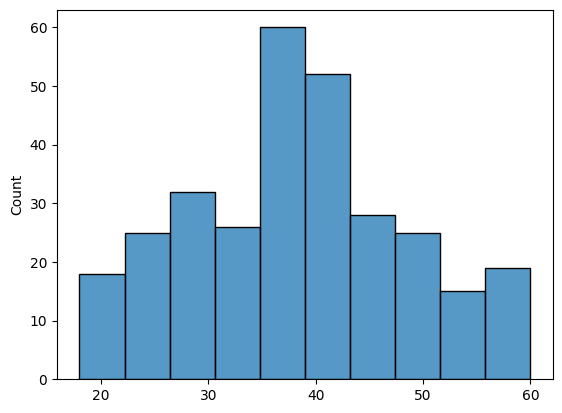

In [65]:
# Vamos observar a distribuição
sns.histplot(X_train[:,0])



<Axes: ylabel='Count'>

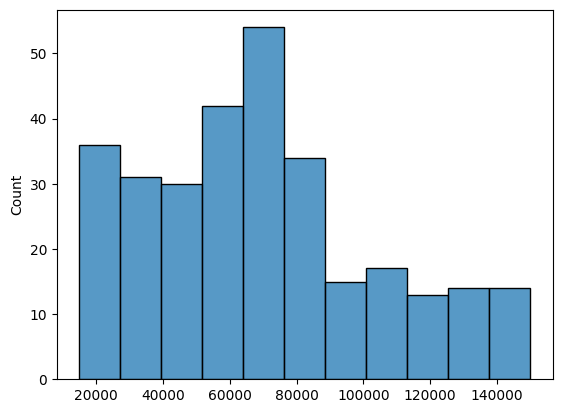

In [66]:
# Vamos observar a distribuição
sns.histplot(X_train[:,1])


In [67]:
# Vamos realizar uma normalização devido a grande diferença nas grandezas
# Utilizaremos a biblioteca sklearn e a função StandardScaler
from sklearn.preprocessing import StandardScaler

# Instanciamos ela
sc = StandardScaler()


# Para utilizar precisamos realizar um fit e um transform, para que realize o calculo de normalização
# e aplique no X_train
X_train_norm = sc.fit_transform(X_train)


# Posteriormente, só aplicamos no X_test
X_test_norm = sc.transform(X_test)


In [68]:
# Observando novamente a variável
X_train_norm


array([[ 0.58164944, -0.88670699],
       [-0.60673761,  1.46173768],
       [-0.01254409, -0.5677824 ],
       [-0.60673761,  1.89663484],
       [ 1.37390747, -1.40858358],
       [ 1.47293972,  0.99784738],
       [ 0.08648817, -0.79972756],
       [-0.01254409, -0.24885782],
       [-0.21060859, -0.5677824 ],
       [-0.21060859, -0.19087153],
       [-0.30964085, -1.29261101],
       [-0.30964085, -0.5677824 ],
       [ 0.38358493,  0.09905991],
       [ 0.8787462 , -0.59677555],
       [ 2.06713324, -1.17663843],
       [ 1.07681071, -0.13288524],
       [ 0.68068169,  1.78066227],
       [-0.70576986,  0.56295021],
       [ 0.77971394,  0.35999821],
       [ 0.8787462 , -0.53878926],
       [-1.20093113, -1.58254245],
       [ 2.1661655 ,  0.93986109],
       [-0.01254409,  1.22979253],
       [ 0.18552042,  1.08482681],
       [ 0.38358493, -0.48080297],
       [-0.30964085, -0.30684411],
       [ 0.97777845, -0.8287207 ],
       [ 0.97777845,  1.8676417 ],
       [-0.01254409,

<Axes: ylabel='Count'>

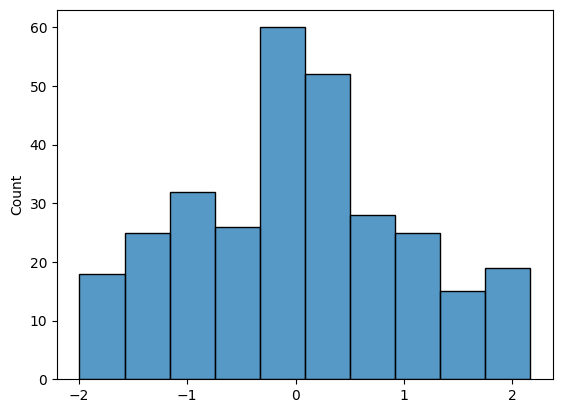

In [69]:
# Vamos observar a distribuição
sns.histplot(X_train_norm[:,0])


In [70]:
# Vamos treinar utilizando o GaussianNB novamente
from sklearn.naive_bayes import GaussianNB


# Instanciando
classifier = GaussianNB()



# Treinando
classifier.fit(X_train_norm, y_train)



GaussianNB()

In [71]:
# Com o algoritimo treinado, podemos predizer novos valores
pred_naive = classifier.predict(X_test_norm)
# Como por exemplo, uma pessoa de 30 anos, com salario de 87000, compraria?
print(classifier.predict(sc.transform([[30,87000]])))

# Para tal, precisamos transformar o valor para dentro da normalização e dai predizer
pred_naive = classifier.predict(sc.transform([[30,87000]]))


[0]


In [72]:
# Verificando a métrica final, com o resultado do X_test
y_pred = classifier.predict(X_test_norm)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)



[[65  3]
 [ 7 25]]


0.9

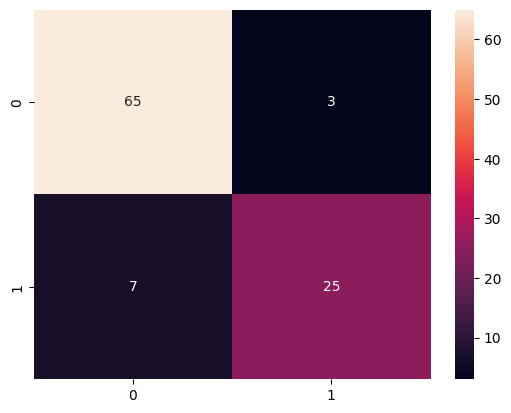

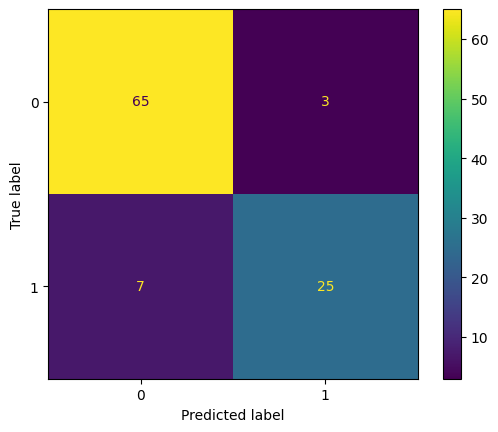

In [73]:
# Podemos visualizar também a matriz de confusão como um heatmap
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()
confusion_matrix_display = ConfusionMatrixDisplay(cm)
confusion_matrix_display.plot()
plt.show()

### Vamos visualizar os resultados do treinamento e do teste

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Teste

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Utilizando o dataset "Spam", aqui é necessária uma outra biblioteca para trabalhar a questão do texto

In [74]:
# Importando o csv para um pandas dataframe
df = pd.read_csv("/content/spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [75]:
# Convertendo as variáveis categóricas para números
df['target'] = df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()


,Category,Message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [76]:
# Aqui a biblioteca sklearn tem uma função chamada CountVectorizer, que transforma a ocorrência de
# cada palavra em uma matriz esparsa
from sklearn.feature_extraction.text import CountVectorizer

# Instanciamos
vect = CountVectorizer(stop_words='english')

# Aplicamos o fit e transforma


# Realizamos a transformação dos valores, somente as características (X)
df_count = vect.fit_transform(df['Message'])

In [77]:
# Descrição da matriz criada
df_count


<5572x8440 sparse matrix of type '<class 'numpy.int64'>'
	with 43529 stored elements in Compressed Sparse Row format>

In [78]:
# Realizando o split dos nossos dados
X = df_count
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
# Observando a dimensão da matriz
df_count.shape


(5572, 8440)

In [80]:
# Para este caso iremos utilizar o Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Instanciamos nosso modelo
classifier_mult = MultinomialNB()


# Treinando o modelo
classifier_mult.fit(X_train, y_train)


MultinomialNB()

In [81]:
# Emails novos para ser predita a classe
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

# Transformação do email em matriz esparsa
emails_count = vect.transform(emails)


# Predição
pred = classifier_mult.predict(emails_count)
pred


array([0, 1])

In [82]:
# Verificação do score do modelo através da acurácia
classifier.score(X_test, y_test)


TypeError: A sparse matrix was passed, but dense data is required. Use X.toarray() to convert to a dense numpy array.

In [ ]:
# Teste da acurácia


## Exercício dataset Titanic

In [83]:
# Importando o csv para um pandas dataframe
df = pd.read_csv("/content/titanic.csv")
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [84]:
# Pandas get Dummies
df_dummies = pd.get_dummies(df['Sex'])
df_dummies.head()



,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [85]:
# Novo dataframe com os dummies
df_novo = pd.concat([df, df_dummies], axis='columns')
df_novo.head()



,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,female,male
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,False,True
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1,True,False
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True,False
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1,True,False
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0,False,True


In [86]:
# Remoção de colunas não relevantes
df_novo.drop(['PassengerId','Name','Sex','female','Ticket','Cabin'],axis='columns',inplace=True)
df_novo.head()


,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,male
0,3,22.0,1,0,7.2500,S,0,True
1,1,38.0,1,0,71.2833,C,1,False
2,3,26.0,0,0,7.9250,S,1,False
3,1,35.0,1,0,53.1000,S,1,False
4,3,35.0,0,0,8.0500,S,0,True


In [87]:
# Visulizando os dados, realizando possíveis transformações
df_novo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Age       714 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
 5   Embarked  889 non-null    object 
 6   Survived  891 non-null    int64  
 7   male      891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(1)
memory usage: 49.7+ KB


In [88]:
# Sklearn LabelEncoder
from sklearn.preprocessing import LabelEncoder

In [89]:
# Instanciando o labelEncoder
le = LabelEncoder()

# Ensure the 'Embarked' column is a 1D array
df_novo['Embarked'] = le.fit_transform(df_novo.Embarked)
df_novo.head()

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,male
0,3,22.0,1,0,7.2500,2,0,True
1,1,38.0,1,0,71.2833,0,1,False
2,3,26.0,0,0,7.9250,2,1,False
3,1,35.0,1,0,53.1000,2,1,False
4,3,35.0,0,0,8.0500,2,0,True


In [90]:
df_novo.isnull().any()

,0
Pclass,False
Age,True
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
male,False


In [91]:
df_novo['Age'] = df_novo['Age'].fillna(df_novo['Age'].mean())

In [92]:
df_novo.isnull().any()

,0
Pclass,False
Age,False
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
male,False


In [93]:
sc = StandardScaler()

X = df_novo.drop('Survived', axis=1)
y = df_novo['Survived']

In [94]:
X_norm = sc.fit_transform(X)

In [95]:
# Divisão em treino e teste/Validação
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)


In [96]:

# Vamos treinar utilizando o GaussianNB novamente
from sklearn.naive_bayes import GaussianNB
# Instanciando
naive_titanic = GaussianNB()
# Treinando
naive_titanic.fit(X_train, y_train)


GaussianNB()

In [97]:
# Medindo o score em relação a uma métrica
naive_titanic.score(X_test, y_test)


0.776536312849162

In [98]:
f1_score(y_test, naive_titanic.predict(X_test))

0.7402597402597403

In [99]:
from sklearn.metrics import classification_report

In [100]:
# Classification report
print(classification_report(y_test, naive_titanic.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



## Exercício dataset Wine ( direto do sklearn )

$ from sklearn import datasets

$ wine = datasets.load_wine()

In [101]:
from sklearn import datasets
wine = datasets.load_wine(as_frame=True)

## Árvore de Decisão

Vamos utilizar agora o algoritimo da árvore de decisão para resolver os mesmos problemas

<img src="figs/arvore_dec.png" width="600" height="600" />



### Exercícios

In [102]:
# Import do dataset
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [103]:
from sklearn.model_selection import train_test_split # Import the necessary function
# Realizando o train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [104]:
# Visualizando train, test
x_train

array([[    44,  39000],
       [    32, 120000],
       [    38,  50000],
       [    32, 135000],
       [    52,  21000],
       [    53, 104000],
       [    39,  42000],
       [    38,  61000],
       [    36,  50000],
       [    36,  63000],
       [    35,  25000],
       [    35,  50000],
       [    42,  73000],
       [    47,  49000],
       [    59,  29000],
       [    49,  65000],
       [    45, 131000],
       [    31,  89000],
       [    46,  82000],
       [    47,  51000],
       [    26,  15000],
       [    60, 102000],
       [    38, 112000],
       [    40, 107000],
       [    42,  53000],
       [    35,  59000],
       [    48,  41000],
       [    48, 134000],
       [    38, 113000],
       [    29, 148000],
       [    26,  15000],
       [    60,  42000],
       [    24,  19000],
       [    42, 149000],
       [    46,  96000],
       [    28,  59000],
       [    39,  96000],
       [    28,  89000],
       [    41,  72000],
       [    45,  26000],


In [105]:
from sklearn.preprocessing import StandardScaler
# Normalizando os dados
# Instanciamos ela
sc = StandardScaler()


# Para utilizar precisamos realizar um fit e um transform, para que realize o calculo de normalização
# e aplique no X_train
X_train_norm = sc.fit_transform(x_train)

# Posteriormente, só aplicamos no X_test
X_test_norm = sc.transform(x_test)

In [106]:
X_test_norm

array([[-0.80480212,  0.50496393],
       [-0.01254409, -0.5677824 ],
       [-0.30964085,  0.1570462 ],
       [-0.80480212,  0.27301877],
       [-0.30964085, -0.5677824 ],
       [-1.10189888, -1.43757673],
       [-0.70576986, -1.58254245],
       [-0.21060859,  2.15757314],
       [-1.99318916, -0.04590581],
       [ 0.8787462 , -0.77073441],
       [-0.80480212, -0.59677555],
       [-1.00286662, -0.42281668],
       [-0.11157634, -0.42281668],
       [ 0.08648817,  0.21503249],
       [-1.79512465,  0.47597078],
       [-0.60673761,  1.37475825],
       [-0.11157634,  0.21503249],
       [-1.89415691,  0.44697764],
       [ 1.67100423,  1.75166912],
       [-0.30964085, -1.37959044],
       [-0.30964085, -0.65476184],
       [ 0.8787462 ,  2.15757314],
       [ 0.28455268, -0.53878926],
       [ 0.8787462 ,  1.02684052],
       [-1.49802789, -1.20563157],
       [ 1.07681071,  2.07059371],
       [-1.00286662,  0.50496393],
       [-0.90383437,  0.30201192],
       [-0.11157634,

In [107]:
# Instanciando e treinando a árvore de decisão
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree = DecisionTreeClassifier()
tree.fit(X_train_norm, y_train)

DecisionTreeClassifier()

In [108]:
from sklearn.metrics import classification_report
# Verificando a metrica
y_pred = tree.predict(X_test_norm)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.94      0.91      0.93        68
           1       0.82      0.88      0.85        32

    accuracy                           0.90       100
   macro avg       0.88      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100



In [109]:
# Predict de um novo valor
x_new = np.array([[25,90000]])

# transform antes do predict
tree.predict(sc.transform(x_new)).item()

0

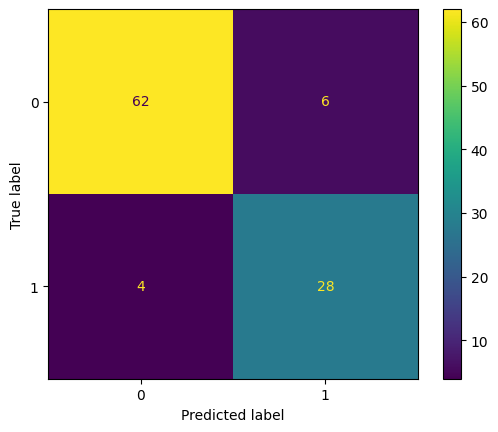

In [110]:
# Utilize o Seaborn heatmap para verificar
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree.classes_)
disp.plot()


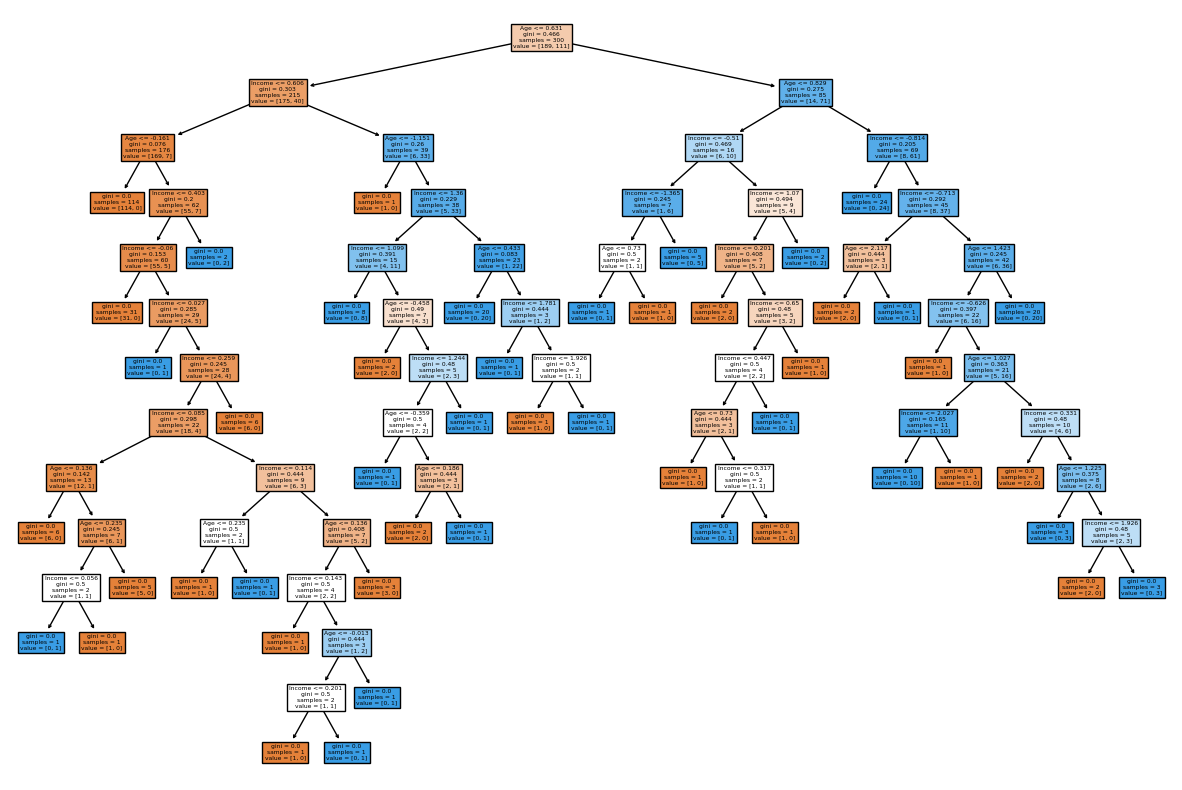

In [111]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Assuming 'tree' is your fitted DecisionTreeClassifier
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
plot_tree(tree, filled=True, feature_names=['Age', 'Income'])  # Replace with your actual feature names
plt.show()

## Visualizando os resultados

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Teste

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Vamos realizar os mesmos exercícios utilizando decision trees para verificar se melhora os resultados

### Titanic

In [112]:
# Import do dataset
df_titanic = pd.read_csv('/content/titanic.csv')

In [113]:
df_titanic

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",2,male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,"Graham, Miss. Margaret Edith",1,female,19.0,0,0,112053,30.0000,B42,S,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,"Behr, Mr. Karl Howell",1,male,26.0,0,0,111369,30.0000,C148,C,1


In [114]:
# Remoção de colunas não relevantes
df_titanic.drop(['PassengerId','Name','Ticket','Cabin'],axis='columns',inplace=True)
df_titanic.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [115]:
dummies = pd.get_dummies(df_titanic['Sex'])

In [116]:
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [117]:
df_titanic = pd.concat([df_titanic, dummies], axis='columns')
df_titanic.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,female,male
0,3,male,22.0,1,0,7.2500,S,0,False,True
1,1,female,38.0,1,0,71.2833,C,1,True,False
2,3,female,26.0,0,0,7.9250,S,1,True,False
3,1,female,35.0,1,0,53.1000,S,1,True,False
4,3,male,35.0,0,0,8.0500,S,0,False,True


In [118]:
df_titanic.drop(['Sex', 'male'], axis='columns', inplace=True)
df_titanic.head()

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female
0,3,22.0,1,0,7.2500,S,0,False
1,1,38.0,1,0,71.2833,C,1,True
2,3,26.0,0,0,7.9250,S,1,True
3,1,35.0,1,0,53.1000,S,1,True
4,3,35.0,0,0,8.0500,S,0,False


In [120]:
df_titanic.isnull().any()

,0
Pclass,False
Age,True
SibSp,False
Parch,False
Fare,False
Embarked,True
Survived,False
female,False


In [121]:
df_titanic.Embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [122]:
df_titanic.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [123]:
df_titanic['Embarked'] = df_titanic['Embarked'].fillna('S')


In [124]:
df_titanic.isnull().any()

,0
Pclass,False
Age,True
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
female,False


In [125]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_titanic['Embarked'] = le.fit_transform(df_titanic.Embarked)
df_titanic.head()

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female
0,3,22.0,1,0,7.2500,2,0,False
1,1,38.0,1,0,71.2833,0,1,True
2,3,26.0,0,0,7.9250,2,1,True
3,1,35.0,1,0,53.1000,2,1,True
4,3,35.0,0,0,8.0500,2,0,False


In [126]:
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].mean())

In [127]:
df_titanic.isnull().any()

,0
Pclass,False
Age,False
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
female,False


In [128]:
sc = StandardScaler()

X_norm = sc.fit_transform(df_titanic.drop('Survived', axis=1))

In [129]:
X_norm.shape

(891, 7)

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, df_titanic['Survived'], test_size=0.2, random_state=42)

In [134]:
tree_titanic = DecisionTreeClassifier()
tree_titanic.fit(X_train, y_train)

DecisionTreeClassifier()

In [135]:
y_pred = tree_titanic.predict(X_test)

In [136]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       105
           1       0.74      0.77      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



### Wine dataset

In [137]:
wine, target = datasets.load_wine(return_X_y=True, as_frame=True)

In [143]:
X_norm = sc.fit_transform(wine)

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, target, test_size=0.2, random_state=42)

In [145]:
tree_wine = DecisionTreeClassifier()
tree_wine.fit(X_train, y_train)

DecisionTreeClassifier()

In [146]:
y_pred = tree_wine.predict(X_test)

In [147]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



## Regression trees com Boston Housing

In [148]:
#load dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [149]:
data.shape

(506, 13)

In [150]:
target.shape

(506,)

In [151]:
from sklearn.tree import DecisionTreeRegressor

In [152]:
X_norm = sc.fit_transform(data)

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, target, test_size=0.15, random_state=0)

In [154]:
tree_boston = DecisionTreeRegressor()
tree_boston.fit(X_train, y_train)

DecisionTreeRegressor()

In [155]:
y_pred = tree_boston.predict(X_test)

In [161]:
from sklearn.metrics import mean_squared_error, r2_score
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.5118238542346409
36.60210526315789


In [ ]:
_